# Assignment 1: Equations non-linéaires

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('./..')
from NonLinearEquationsLib import plotPhi, plotPhiIterations

## Partie 1

Ecrivez une fonction pour l'algorithme d'iterations de point fixe avec la structure suivante:
```python
def  FixedPoint( phi, x0, a, b, tol, nmax ) :
    '''
    FixedPoint - Find the fixed point of a function by iterative iterations
    
    FixedPoint(PHI, X0, a, b, TOL, NMAX) tries to find the fixed point X of the
    continuous function PHI starting from X0 using the fixed point iterations method. 
    The fixed point is searched within the interval [a,b]; if one iterate exits 
    the interval, the method stops and an error message is displayed.
    If the search of the fixed point fails an error message is displayed.
    
    Inputs : [phi, x0, a, b, tol, nmax]
    phi : function for which a fixed point is searched
    x0 : initial guess on the fixed point of phi
    a : left extrema of the interval where to look for a fixed point of phi
    b : right extrema of the interval where to look for a fixed point of phi
    tol : tolerance on the increment, below which the iterations are stopped
    nmax : maximum number of iterations, above which the iterations are stopped and 
           an error message is displayed
     
    Outputs : [x, r, n, inc, x_sequence]
    x : the approximated fixed point of the function
    r : the absolute value of the residual in x, i.e. |phi(x) - x|
    n : the number of iterations required to compute x 
    inc : the sequence of the increments of the fixed point method
    x_sequence : the sequence of iterates computed by the fixed point method
       
    '''
```

In [2]:
def FixedPoint( phi, x0, a, b, tol, nmax ):
    
    # Initial values
    n = 0
    xk = x0
    rk = b-a
    
    # initialisation of loop components
    # increments (in abs value) at each iteration
    inc = []
    # define the sequence of iterates
    x = [x0]
    # initialize the current iterate to the initial guess
    xk = x0
    # diff: last increment, initially set larger then tolerance
    diff = 2*tol 
    
    # TODO: COMPLETE THE CODE BELOW

    for k in range(nmax):
        xk = x[k]
        rk = abs(phi(xk)-xk)

        if k == 0 :
            inc.append(abs(xk))
        else :
            inc.append(abs(x[k]-x[k-1]))

        x.append(phi(xk))

        if rk < tol :
            return xk, rk, k, inc, np.array(x)
    
    # 1. Perform fixed point iterations
    # 2. Compute the residual
    
    # Warning if not converged; Info message if converged
    if n > nmax :
        print('FixexPoint stopped without converging to the desired tolerance ')
        print('because the maximum number of iterations was reached')
    elif (xk<=a) or (xk >= b) :
        print(f'Fixed point method has stopped as iterate {n} equals {xk} and it is ')
        print(f'outside of the prescribed interval [{a};{b}].')
    else :
        print(f'Fixed Point method converged in {n} iterations. Residual value: {rk}')
    
    return xk, rk, n, inc, np.array(x)

## Partie 2

On considère les méthodes de point fixe $x^{(n+1)} = \phi_i(x^{(n)})
\ \ (i=1,2,3) \ $ avec:

$$\phi_1(x) = 2\ln(2x-1), \qquad \phi_2(x) = \dfrac12 (1-e^{x/2}), \qquad \phi_3(x) = \dfrac12 (1+e^{x/2})$$
  
Vous pouvez visualiser les fonctions d'itération $\phi_i(x)$ en executant la prochaine cellule.

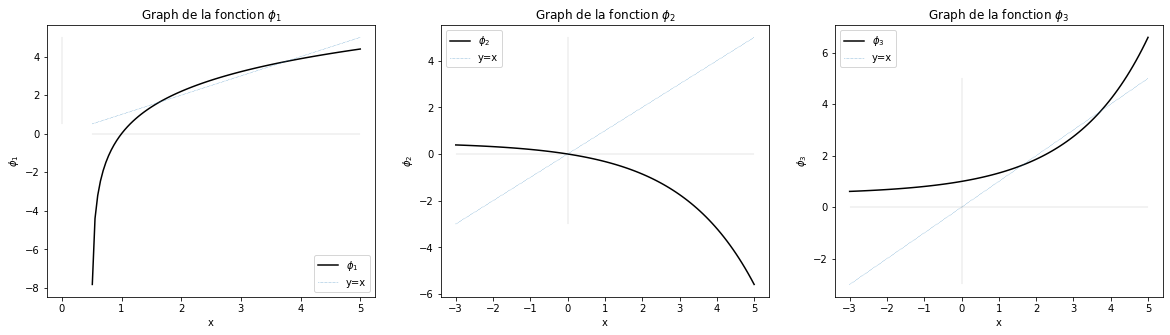

In [3]:
plt.rcParams['figure.figsize'] = [20, 5]

plt.subplot(1,3,1)
[a,b] = [0.5+1e-2,5]
phi1 = lambda x : 2*np.log(2*x-1)  
plotPhi(a,b,phi1,'$\phi_1$')

plt.subplot(1,3,2)
[a,b] = [-3,5]
phi2 = lambda x : 1/2 * (-np.exp(x/2) +1)
plotPhi(a,b,phi2,'$\phi_2$')

plt.subplot(1,3,3)
[a,b] = [-3,5]
phi3 = lambda x : 1/2 * (np.exp(x/2) +1)
plotPhi(a,b,phi3,'$\phi_3$')

plt.show()

Pour chaque point fixe $\bar{x}^i_k$ de chaque fonction d'itération $\phi_i$ ($i=1,2,3$), on suppose choisir une valeur initiale $x^{(0)}$ qui soit proche de $\bar{x}^i_k$. Etudier la **convergence locale** de la méthode vers $\bar{x}^i_k$, en executant les cellules ci-dessous.

### Test avec fonction $\phi_1$

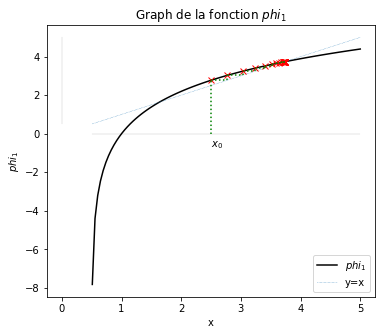

In [4]:
tol  = 1e-4
nmax = 50

# Choose fonction phi
[a,b] = [0.5+1e-2,5]
phi = phi1
label = '$phi_1$'

# Initial Point
x0 = 2.5  # you can change this value to see when convergence occurs and when it does not

# Fixed Point Iterations
zero1, residual1, niter1, inc1, x1 = FixedPoint(phi,x0,a,b,tol,nmax)

plt.subplot(131)
plotPhi (a,b,phi,label)
plt.plot(x1,phi(x1), 'rx')

# plot the graphical interpretation of the Fixed Point method
plotPhiIterations(x1)

plt.show()

### Test avec fonction $\phi_2$

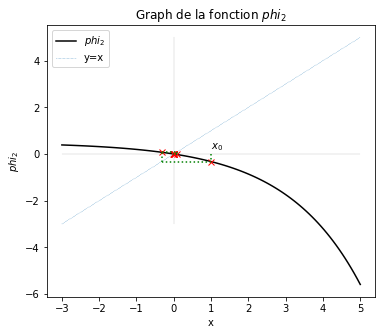

In [5]:
tol  = 1e-4
nmax = 50

# Choose fonction phi
[a,b] = [-3, 5]
phi = phi2
label = '$phi_2$'

# Initial Point
x0 = 1  # you can change this value to see when convergence occurs and when it does not

# Fixed Point Iterations
zero2, residual2, niter2, inc2, x2 = FixedPoint(phi,x0,a,b,tol,nmax)

plt.subplot(131)
plotPhi (a,b,phi,label)
plt.plot(x2,phi(x2), 'rx')

# plot the graphical interpretation of the Fixed Point method
plotPhiIterations(x2)

plt.show()

### Test avec fonction $\phi_3$

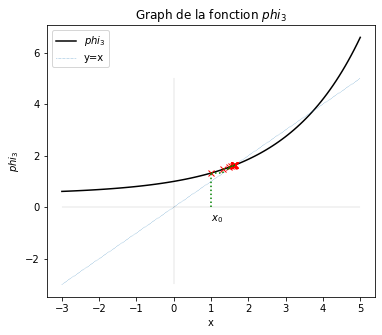

In [6]:
tol  = 1e-4
nmax = 50

# Choose fonction phi
[a,b] = [-3,5]
phi = phi3
label = '$phi_3$'

# Initial Point
x0 = 1  # you can change this value to see when convergence occurs and when it does not

# Fixed Point Iterations
zero3, residual3, niter3, inc3, x3 = FixedPoint(phi,x0,a,b,tol,nmax)

plt.subplot(131)
plotPhi (a,b,phi,label)
plt.plot(x3,phi(x3), 'rx')

# plot the graphical interpretation of the Fixed Point method
plotPhiIterations(x3)

plt.show()

## Commentaire
Donnez un petit commentaire sur les resultats que vous avez obtenus. En particulier, pour toute fonction, discutez la convergence de la méthode de point fixe et, s'il y a convergence, avec quel ordre et pourquoi.

### Réponse 1
Ecrivez ici votre commentaire sur les solutions obtenues (double-cliquez sur cette cellule)

Pour phi1, la convergence est d'ordre 2 car pour une fonction f qui a un zéro en les points fixes de phi1, la dérivée de f en ces points n'est pas nulle.

Pour phi2, la convergence est d'ordre 2 car pour une fonction f qui a un zéro en les points fixes de phi2, la dérivée de f en ces points n'est pas nulle.

Pour phi3, la convergence est d'ordre 2 car pour une fonction f qui a un zéro en les points fixes de phi3, la dérivée de f en ces points n'est pas nulle.

## Partie 3
On defini la fonction $f$ comme suit: 
$$f(x) = e^x - (2x-1)^2$$ 
Pouvez-vous déduire le lien entre $f$ et les fonctions $\{\phi_i\}_{i=1}^3$ précédemment définies? Completez et executez la cellule suivante pour obtenir un petit indice...

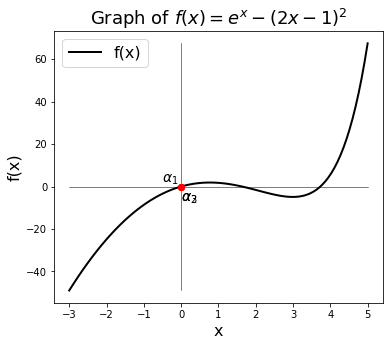

In [7]:
N = 100
[a, b] = [-3, 5]
z = np.linspace(a,b,N)
f = lambda x : np.exp(x) - (1-2*x)**2

plt.subplot(1,3,1)
plt.plot(z,f(z),'k-', linewidth=2)

plt.xlabel('x', fontsize=16)
plt.ylabel('f(x)', fontsize=16)
# Plot the x,y-axis 
plt.plot([a,b], [0,0], 'k-',linewidth=0.5)
plt.plot([0,0], [np.min(f(z)),np.max(f(z))], 'k-',linewidth=0.5)
plt.legend(['f(x)'], fontsize=16)
plt.title('Graph of $f(x)=e^x-(2x-1)^2$', fontsize=18)

# TODO: which values should be put in place of the zeros to visualize the correct answer?
alpha = np.array([0.0, 0.0, 0.0])

plt.plot(alpha,f(alpha),'ro')
plt.annotate("$\\alpha_3$", (alpha[0], -7), fontsize=14)
plt.annotate("$\\alpha_1$", (alpha[1]-0.5, 2), fontsize=14)
plt.annotate("$\\alpha_2$", (alpha[2], -7), fontsize=14)

plt.show()

### Réponse 2
Ecrivez ici votre rèponse à la question de la partie 3 (double-cliquez sur cette cellule)


f(alpha) = 0 pour phi(alpha) = alpha

f(x) = -exp(phi1(x)) -4*phi2(x)*phi(3) +1

## Partie 4

D'après les résultats vus en classe, est-il possible de définir une autre fonction $\phi_4$ qui a la même propriété que les $\{\phi_i\}_{i=1}^3$ par rapport à $f$? Si oui, écrivez son expression dans la cellule suivante et exécutez-la pour vérifier le résultat des itérations de point fixe. Puis expliquez comment vous avez derivé son expression et discutez la convergence locale de la méthode.

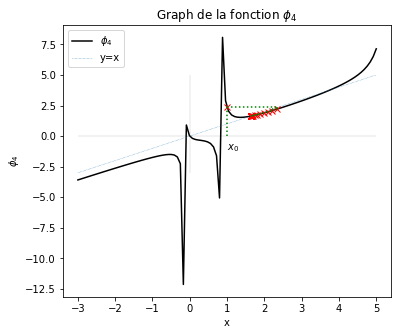

In [8]:
# WRITE HERE THE RIGHT EXPRESSION OF THE FUNCTION!
phi = lambda x: x - f(x)/(np.exp(x)-4*x*(2*x-1))

tol  = 1e-4
nmax = 50

# Choose fonction phi
[a,b] = [-3,5]
label = '$\phi_4$'

# Initial Point
x0 = 1  # you can change this value to see when convergence occurs and when it does not

# Fixed Point Iterations
zero4, residual4, niter4, inc4, x4 = FixedPoint(phi,x0,a,b,tol,nmax)

plt.subplot(131)
plotPhi (a,b,phi,label)
plt.plot(x4, phi(x4), 'rx')

# plot the graphical interpretation of the Fixed Point method
plotPhiIterations(x4)

plt.show()

### Réponse 3

Ecrivez ici votre rèponse à la question de la partie 4 (double-cliquez sur cette cellule)

Oui, en utilisant la methode de Newton il est possible d'avoir une autre expression de phi : x - f(x)/(np.exp(x)-4*x*(2*x-1)) 
Or il faut verifier la continuité de phi sinon la methode convergera ou pas selon le choix de x0.